Unveiling the Android App Market

Problem Statement
The goal of this project is to analyze Google Play Store data to understand app market trends, user preferences, and business insights using data analytics and visualization.

#### 1. Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### 2. Loading Dataset

In [3]:
apps = pd.read_csv("apps.csv")
reviews = pd.read_csv("user_reviews.csv")
apps.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


#### 3. Data Understanding

In [4]:
apps.info()
apps.describe()
apps.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB


Unnamed: 0           0
App                  0
Category             0
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

#### 4.Data Cleaning

In [5]:
# Fixing missing values
apps.drop_duplicates(inplace=True)
apps.dropna(inplace=True)

In [6]:
# Size column conversion
apps['Size'] = pd.to_numeric(apps['Size'], errors='coerce')

In [7]:
# Cleaning installs
apps['Installs'] = apps['Installs'].str.replace('+','')
apps['Installs'] = apps['Installs'].str.replace(',','')
apps['Installs'] = apps['Installs'].astype(int)

In [16]:
# Clean Price
apps['Price'] = apps['Price'].astype(str)
apps['Price'] = apps['Price'].str.replace('$','')
apps['Price'] = apps['Price'].astype(float)

#### 5. Category Exploration

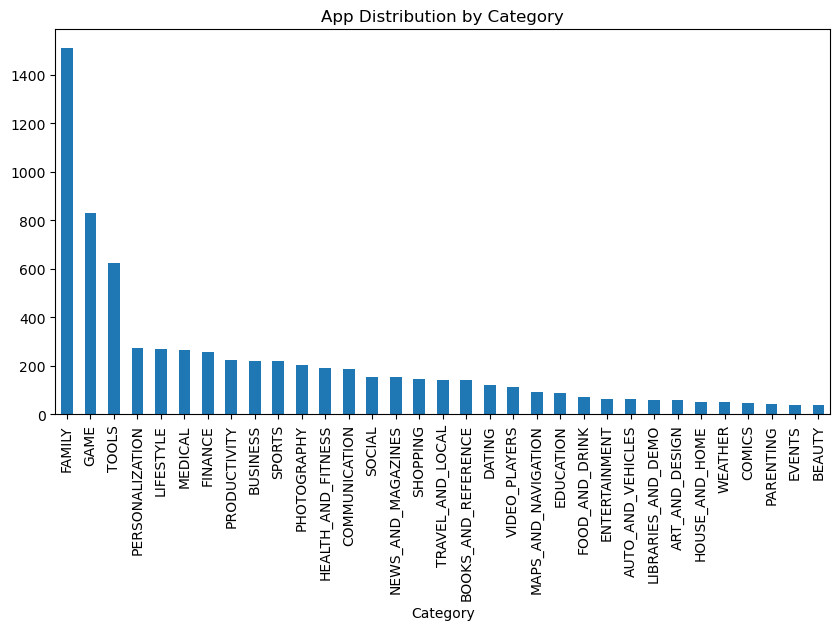

In [9]:
apps['Category'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("App Distribution by Category")
plt.show()

#### 6. Ratings Analysis

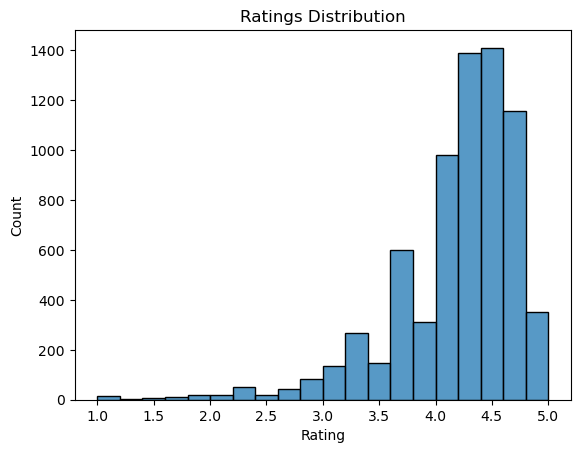

In [10]:
sns.histplot(apps['Rating'], bins=20)
plt.title("Ratings Distribution")
plt.show()

#### 7. Free vs Paid Apps

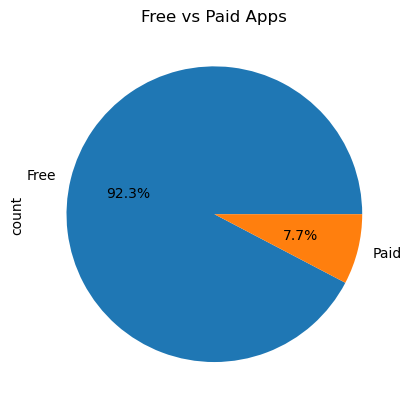

In [11]:
apps['Type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Free vs Paid Apps")
plt.show()

#### 8. Price Analysis

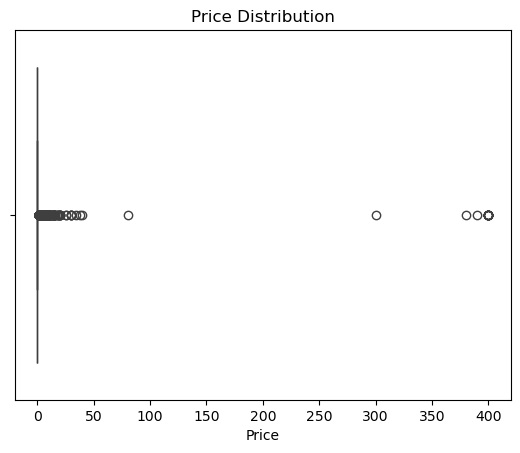

In [12]:
sns.boxplot(x=apps['Price'])
plt.title("Price Distribution")
plt.show()

#### 9. Popularity Analysis

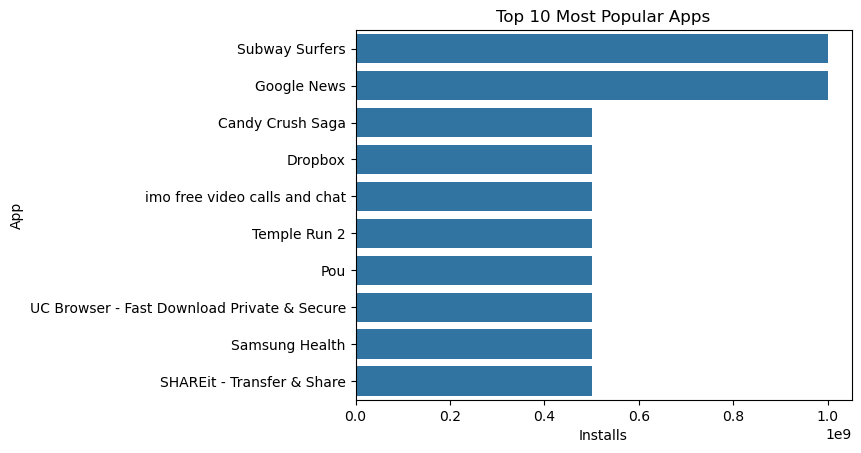

In [13]:
top_apps = apps.sort_values(by='Installs', ascending=False).head(10)
sns.barplot(x=top_apps['Installs'], y=top_apps['App'])
plt.title("Top 10 Most Popular Apps")
plt.show()

#### 10. Sentiment Analysis (Reviews)

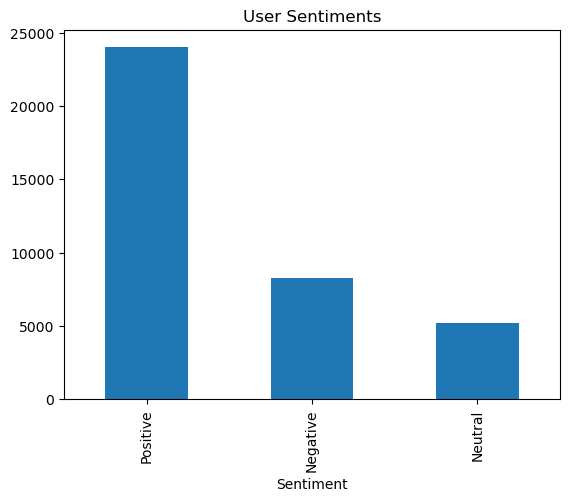

In [14]:
reviews.head()
reviews['Sentiment'].value_counts().plot(kind='bar')
plt.title("User Sentiments")
plt.show()

#### 11. Key Insights

- Most apps are free  
- Few categories dominate the market  
- High-rated apps attract more users  
- Paid apps are less popular  
- User sentiment is mostly positive  

#### 12. Recommendations

- Focus on popular categories  
- Improve app ratings for better engagement  
- Offer free versions to attract users  
- Monitor user reviews for improvements  

#### 13. Conclusion

The analysis provides valuable insights into app market trends, user behavior, and business strategies.

Data analytics helps in making better decisions for app development and marketing.

#### 14. Savinng Output

In [17]:
apps.to_csv("cleaned_apps.csv", index=False)